In [2]:
# Importando as bibliotecas que usaremos no projeto.
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
# Carregando o dataset e visualizando as primeiras linhas.
df = pd.read_csv("data/Coffee Shop Sales.csv")
print("Primeiras 5 linhas do dataset:")
df.head()

Primeiras 5 linhas do dataset:


,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,1/1/23,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,1/1/23,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,1/1/23,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,1/1/23,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,1/1/23,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [23]:
print("Informações do Dataset:")
df.info()

Informações do Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   transaction_date  149116 non-null  str    
 2   transaction_time  149116 non-null  str    
 3   transaction_qty   149116 non-null  int64  
 4   store_id          149116 non-null  int64  
 5   store_location    149116 non-null  str    
 6   product_id        149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   product_category  149116 non-null  str    
 9   product_type      149116 non-null  str    
 10  product_detail    149116 non-null  str    
dtypes: float64(1), int64(4), str(6)
memory usage: 12.5 MB


In [4]:
print(f"Quantidade de linhas do dataset: {df.shape[0]}")
print(f"Quantidade de colunas do dataset: {df.shape[1]}")

Quantidade de linhas do dataset: 149116
Quantidade de colunas do dataset: 11


In [24]:
informacoes_adicionais = pd.DataFrame({
    "nulos" : df.isnull().sum(),
    "valores_unicos" : df.nunique()
})
print(f"Informações adicionais do dataset:\n{informacoes_adicionais}")

Informações adicionais do dataset:
                  nulos  valores_unicos
transaction_id        0          149116
transaction_date      0             181
transaction_time      0           25762
transaction_qty       0               6
store_id              0               3
store_location        0               3
product_id            0              80
unit_price            0              41
product_category      0               9
product_type          0              29
product_detail        0              80


In [25]:
print("Estatísticas descritivas do dataset:")
df.describe().round(2)

Estatísticas descritivas do dataset:


,transaction_id,transaction_qty,store_id,product_id,unit_price
count,149116.00,149116.00,149116.00,149116.00,149116.00
mean,74737.37,1.44,5.34,47.92,3.38
std,43153.60,0.54,2.07,17.93,2.66
min,1.00,1.00,3.00,1.00,0.80
25%,37335.75,1.00,3.00,33.00,2.50
50%,74727.50,1.00,5.00,47.00,3.00
75%,112094.25,2.00,8.00,60.00,3.75
max,149456.00,8.00,8.00,87.00,45.00


In [31]:
# Criando a coluna de receita (revenue) multiplicando a quantidade de transações pelo preço unitário.
df['revenue'] = df['transaction_qty'] * df['unit_price']


In [34]:
# Agrupando os dados por data da transação e calculando o total de transações e receita total por dia.
df_diario = df.groupby('transaction_date').agg(
    transacoes_totais = ('transaction_qty', 'count'),
    receita_total = ('revenue', 'sum')
).reset_index()


In [35]:
df_diario.head()

,transaction_date,transacoes_totais,receita_total
0,1/1/23,550,2508.20
1,1/10/23,602,2685.65
2,1/11/23,561,2555.75
3,1/12/23,534,2327.70
4,1/13/23,625,3033.60


In [ ]:
# Complementando as estatísticas descritivas do dataset diário com a amplitude.
resumo = df_diario.describe().round(2)
resumo.loc['amplitude'] = resumo.loc['max'] - resumo.loc['min']
print(f"Estatísticas descritivas do dataset diário:\n{resumo}")

Estatísticas descritivas do dataset diário:
           transacoes_totais  receita_total
count                 181.00         181.00
mean                  823.85        3860.84
std                   246.64        1187.82
min                   459.00        2037.10
25%                   597.00        2853.15
50%                   753.00        3523.26
75%                  1062.00        4850.06
max                  1343.00        6403.91
amplitude             884.00        4366.81


<Axes: xlabel='transacoes_totais', ylabel='receita_total'>

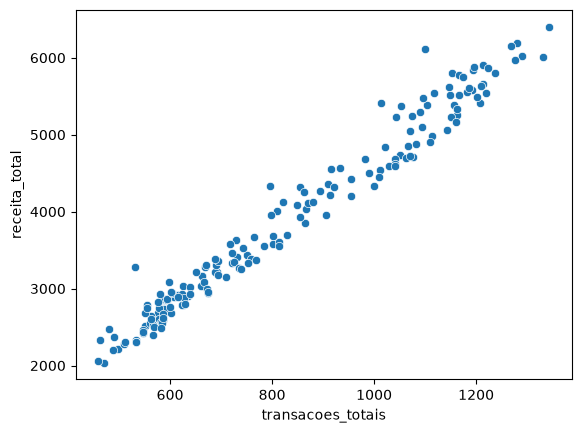

In [ ]:
# Visualizando a relação entre o total de transações e a receita total por dia.
sns.scatterplot(data=df_diario, x='transacoes_totais', y='receita_total')

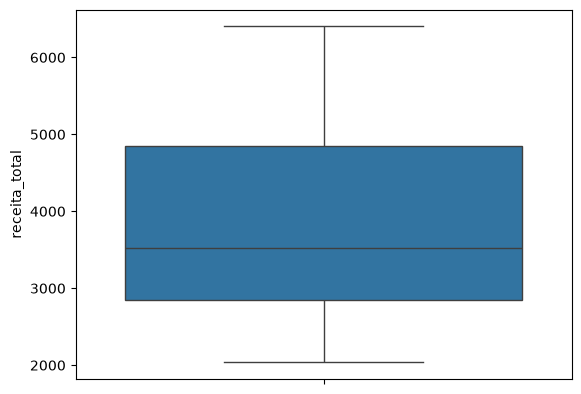

In [48]:

sns.boxplot(data=df_diario, y='receita_total')
plt.show()